# **Shahriar Islam        241000461**

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [ ]:
from google.colab import files
import pandas as pd

# Upload the file
uploaded = files.upload()

# Load the uploaded CSV file into a pandas DataFrame
data = pd.read_csv(list(uploaded.keys())[0])

# Show the first few rows of the dataset
data.head()

Saving Data.Main.Cleaned - Colab - DVIV.csv to Data.Main.Cleaned - Colab - DVIV.csv


,Gender,Age Group,Occupation,Education,Monthly Income,EE,understand,convenient,easy to conduct,SI,...,PR,amount of risk,unpredictability,security risk,advantages over,AI,adopt in future,use regularly,advise others to use,Unnamed: 34
0,0,2,2,3,2,5,5,5,5,5,...,2,2,2,3,1,5,5,5,5,NaN
1,0,2,1,3,3,4,4,5,4,5,...,4,4,3,2,5,5,5,5,5,NaN
2,1,3,3,3,4,5,5,5,5,5,...,3,2,2,3,5,5,5,5,5,NaN
3,1,2,1,3,1,5,4,5,5,4,...,3,3,4,4,2,5,5,5,5,NaN
4,0,2,1,2,3,5,4,5,5,5,...,3,2,2,2,5,5,5,5,5,NaN


In [ ]:
# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Gender                        0
Age Group                     0
Occupation                    0
Education                     0
Monthly Income                0
EE                            0
understand                    0
 convenient                   0
easy to conduct               0
SI                            0
People who are important      0
People who influence          0
 opinions I value             0
FC                            0
 necessary resources          0
 necessary knowledge          0
 compatible                   0
PV                            0
 benefits me                  0
worthwhile                    0
good value                    0
 PT                           0
reliable                      0
secure                        0
trustworthy                   0
PR                            0
amount of risk                0
unpredictability              0
security risk                 0
advantages over               0
AI                     

In [ ]:
# Drop unnamed columns if they exist
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]

In [ ]:
# Check the shape of the dataset
print(f"Dataset Dimensions: {data.shape}")

Dataset Dimensions: (407, 34)


In [ ]:
# Check data types
print("\nData Types:")
print(data.dtypes)


Data Types:
Gender                      int64
Age Group                   int64
Occupation                  int64
Education                   int64
Monthly Income              int64
EE                          int64
understand                  int64
 convenient                 int64
easy to conduct             int64
SI                          int64
People who are important    int64
People who influence        int64
 opinions I value           int64
FC                          int64
 necessary resources        int64
 necessary knowledge        int64
 compatible                 int64
PV                          int64
 benefits me                int64
worthwhile                  int64
good value                  int64
 PT                         int64
reliable                    int64
secure                      int64
trustworthy                 int64
PR                          int64
amount of risk              int64
unpredictability            int64
security risk               int64
a

In [ ]:
columns_to_keep = ["Gender", "Age Group", "Occupation", "Education", "Monthly Income", "EE", "SI", "FC", "PV", " PT", "PR", "AI"]
data = data[columns_to_keep]

In [ ]:
# Display the columns of the DataFrame
print("\nData Columns:")
data.columns


Data Columns:


Index(['Gender', 'Age Group', 'Occupation', 'Education', 'Monthly Income',
       'EE', 'SI', 'FC', 'PV', ' PT', 'PR', 'AI'],
      dtype='object')

In [ ]:
# Display summary statistics
print("\nSummary Statistics:")
print(data.describe(include='all'))


Summary Statistics:
           Gender   Age Group  Occupation   Education  Monthly Income  \
count  407.000000  407.000000  407.000000  407.000000      407.000000   
mean     0.380835    2.461916    1.970516    2.722359        2.513514   
std      0.486190    1.097646    0.930658    1.107105        1.227432   
min      0.000000    1.000000    1.000000    1.000000        1.000000   
25%      0.000000    2.000000    1.000000    2.000000        1.000000   
50%      0.000000    2.000000    2.000000    3.000000        3.000000   
75%      1.000000    3.000000    3.000000    3.000000        3.000000   
max      1.000000    5.000000    4.000000    5.000000        5.000000   

               EE          SI          FC          PV          PT          PR  \
count  407.000000  407.000000  407.000000  407.000000  407.000000  407.000000   
mean     4.324324    4.299754    4.277641    4.196560    4.233415    2.594595   
std      0.468698    0.469330    0.495364    0.695296    0.536421    0.687875 

**Exploratory Data Analysis(EDA)**


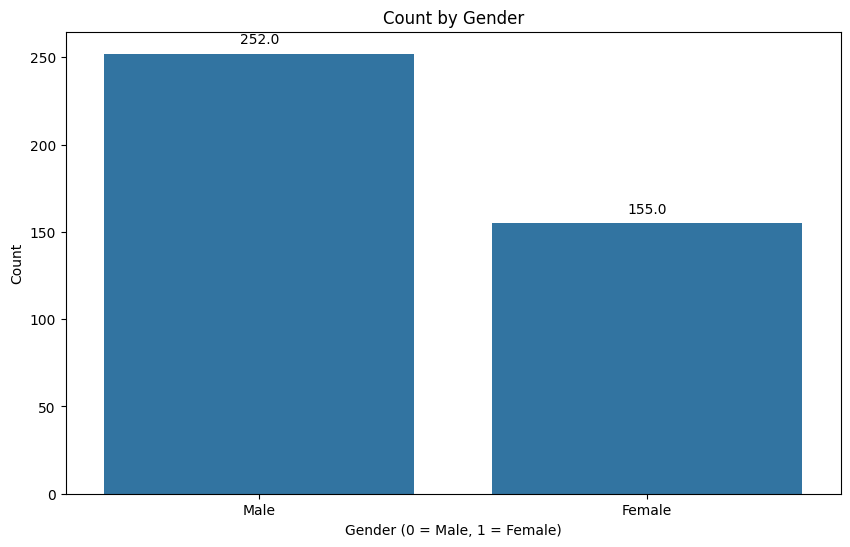

In [ ]:
# Bar Chart for a categorical variable
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=data, x='Gender')  # Store the axes object

plt.title('Count by Gender')
plt.xlabel('Gender (0 = Male, 1 = Female)')
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])
plt.ylabel('Count')

# Add count numbers on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

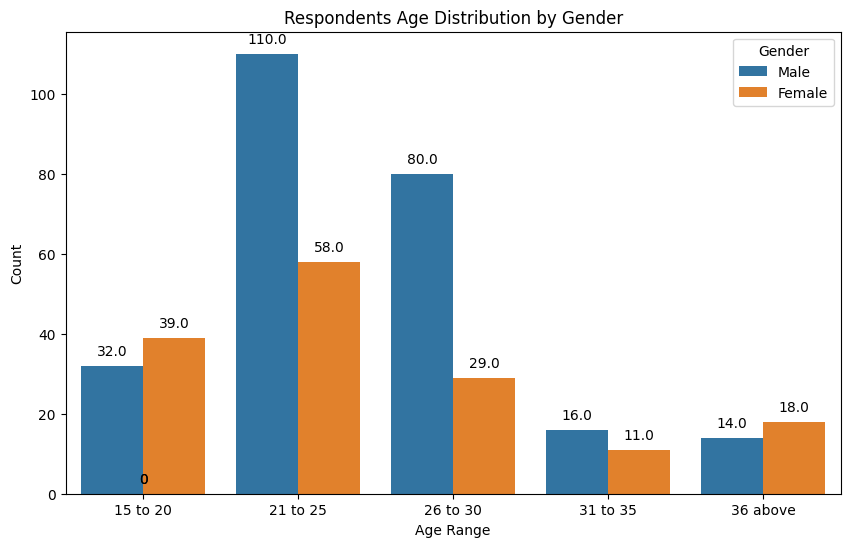

In [ ]:
# Grouped Bar Chart
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=data, x='Age Group', hue='Gender', hue_order=[0, 1])
plt.title('Respondents Age Distribution by Gender')

# Update x-axis labels to represent the age ranges
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=[
    '15 to 20',
    '21 to 25',
    '26 to 30',
    '31 to 35',
    '36 above'
])

# Customize the legend labels for gender
plt.legend(title='Gender', labels=['Male', 'Female'])

plt.xlabel('Age Range')
plt.ylabel('Count')

# Add count numbers on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

In [ ]:
# Dropping the 36 above male(14) and Female(18)  from the dataset

# Filter out rows where 'Age Group' is '36 above' and 'Gender' is Male (0) or Female (1)
data = data[~((data['Age Group'] == 5) & ((data['Gender'] == 0) | (data['Gender'] == 1)))]


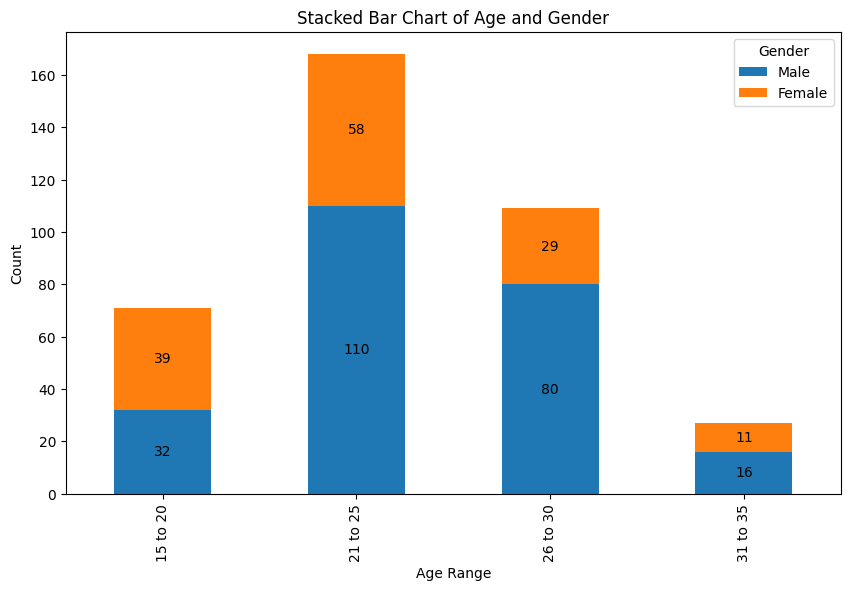

In [ ]:
# Stacked Bar Chart
age_gender_counts = data.groupby(['Age Group', 'Gender']).size().unstack()

# Create the stacked bar chart
ax = age_gender_counts.plot(kind='bar', stacked=True, figsize=(10, 6))

# Customize the title, axis labels, and legend
plt.title('Stacked Bar Chart of Age and Gender')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3,], labels=[
    '15 to 20',
    '21 to 25',
    '26 to 30',
    '31 to 35',

])
plt.legend(title='Gender', labels=['Male', 'Female'])

# Add count numbers on top of bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2,
            y + height / 2,
            '{:.0f}'.format(height),
            horizontalalignment='center',
            verticalalignment='center')


plt.show()

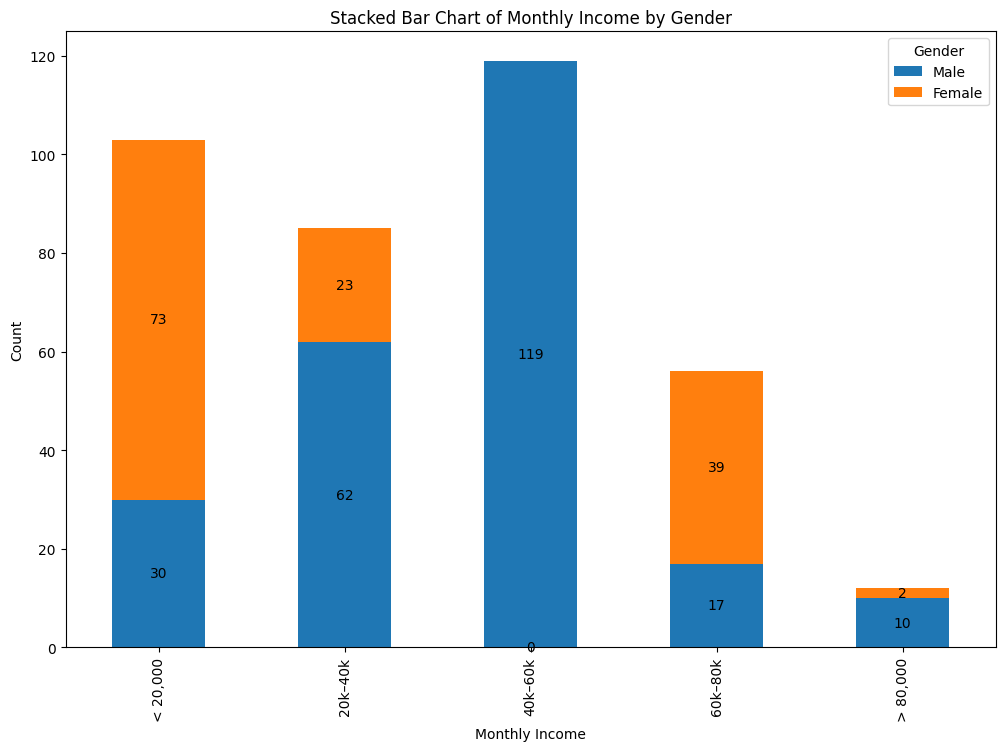

In [ ]:
#Stacked Bar Chart Monthly_Income_Gender_counts
Monthly_Income_Gender_counts = data.groupby(['Monthly Income', 'Gender']).size().unstack()

# Create the stacked bar chart
ax = Monthly_Income_Gender_counts.plot(kind='bar', stacked=True, figsize=(12, 8))

# Customize the chart
plt.title('Stacked Bar Chart of Monthly Income by Gender')
plt.xlabel('Monthly Income')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3, 4],
    labels=[
        '< 20,000',
        '20k–40k',
        '40k–60k',
        '60k–80k',
        '> 80,000',
     ])
plt.legend(title='Gender', labels=['Male', 'Female'])

# Add count numbers on top of bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2,
            y + height / 2,
            '{:.0f}'.format(height),
            horizontalalignment='center',
            verticalalignment='center')

plt.show()

**Visualization of Numeric Variables:**

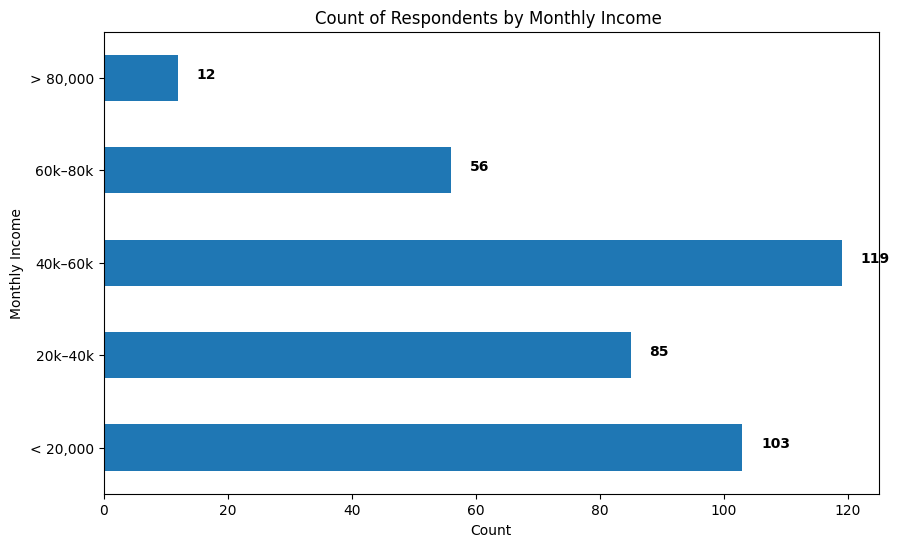

In [ ]:
# Horizontal Bar Chart
plt.figure(figsize=(10, 6))

# Create the horizontal bar chart
ax = data['Monthly Income'].value_counts().sort_index().plot(kind='barh')

# Customize the title and axis labels
plt.title('Count of Respondents by Monthly Income ')
plt.xlabel('Count')
plt.ylabel('Monthly Income')
plt.yticks(ticks=[0, 1, 2, 3, 4],
    labels=[
        '< 20,000',
        '20k–40k',
        '40k–60k',
        '60k–80k',
        '> 80,000'
    ])

# Add count numbers inside the bars
for i, v in enumerate(data['Monthly Income'].value_counts().sort_index()):
    ax.text(v + 3, i, str(v), color='black', fontweight='bold')

plt.show()

<ipython-input-42-93cf5c233b79>:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data['Monthly Income'], shade=True)


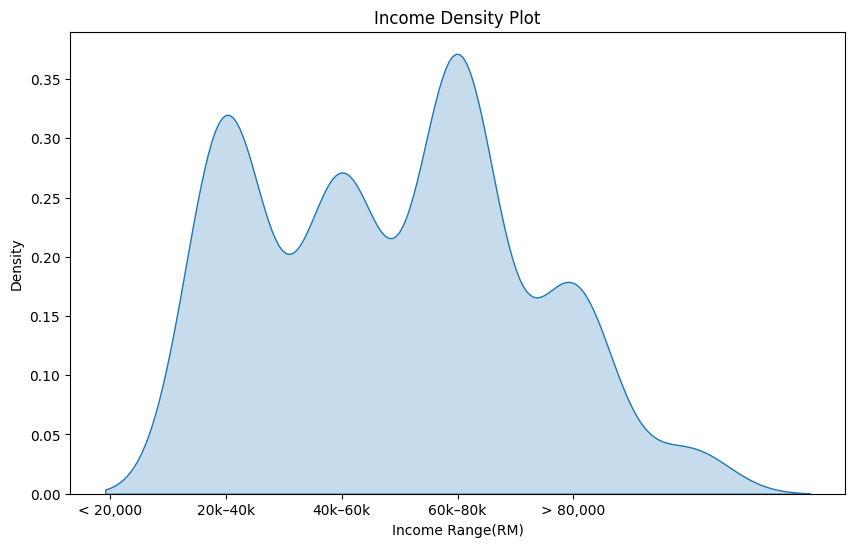

In [ ]:
# Density Plot
plt.figure(figsize=(10, 6))

# Plot the KDE with shaded area
sns.kdeplot(data['Monthly Income'], shade=True)

# Customize the chart
plt.title('Income Density Plot')
plt.xlabel('Income Range(RM)')
plt.ylabel('Density')

# Update x-axis ticks to represent income categories
plt.xticks(
    ticks=[0, 1, 2, 3, 4],
    labels=[
        '< 20,000',
        '20k–40k',
        '40k–60k',
        '60k–80k',
        '> 80,000'
    ]
)

plt.show()

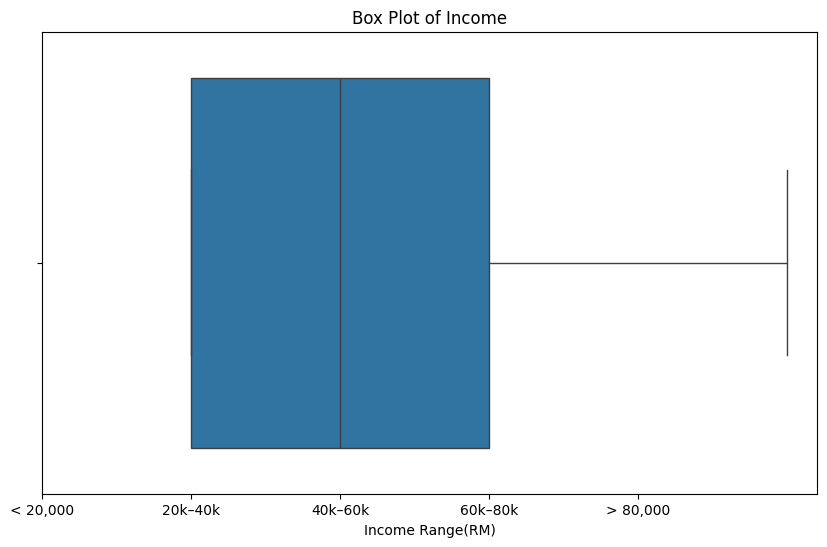

In [ ]:
# Box Plot for Income
plt.figure(figsize=(10, 6))

# Plot the box plot
sns.boxplot(x=data['Monthly Income'])

# Customize the chart
plt.title('Box Plot of Income')
plt.xlabel('Income Range(RM)')

# Update x-axis ticks to represent income categories
plt.xticks(
    ticks=[0, 1, 2, 3, 4],
    labels=[
        '< 20,000',
        '20k–40k',
        '40k–60k',
        '60k–80k',
        '> 80,000'
    ]
)

plt.show()

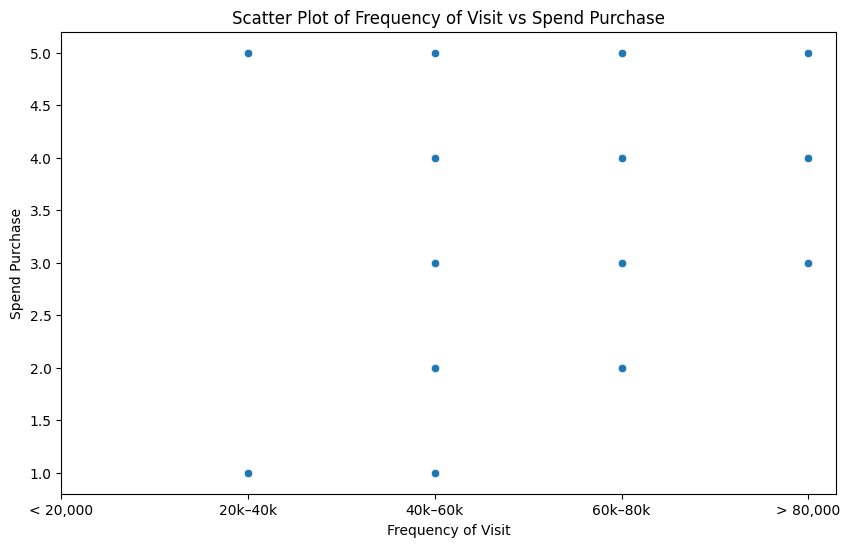

In [ ]:
# Scatter Plot for Frequency of Visits vs. Spend Purchase
plt.figure(figsize=(10, 6))

# Plot the scatter plot
sns.scatterplot(x='Age Group', y='Monthly Income', data=data)

# Customize the chart
plt.title('Scatter Plot of Frequency of Visit vs Spend Purchase')
plt.xlabel('Frequency of Visit')
plt.ylabel('Spend Purchase')

# Update x-axis ticks to represent visit frequency categories
plt.xticks(
    ticks=[0, 1, 2, 3, 4],
    labels=[
        '< 20,000',
        '20k–40k',
        '40k–60k',
        '60k–80k',
        '> 80,000'
    ]
)
plt.show()

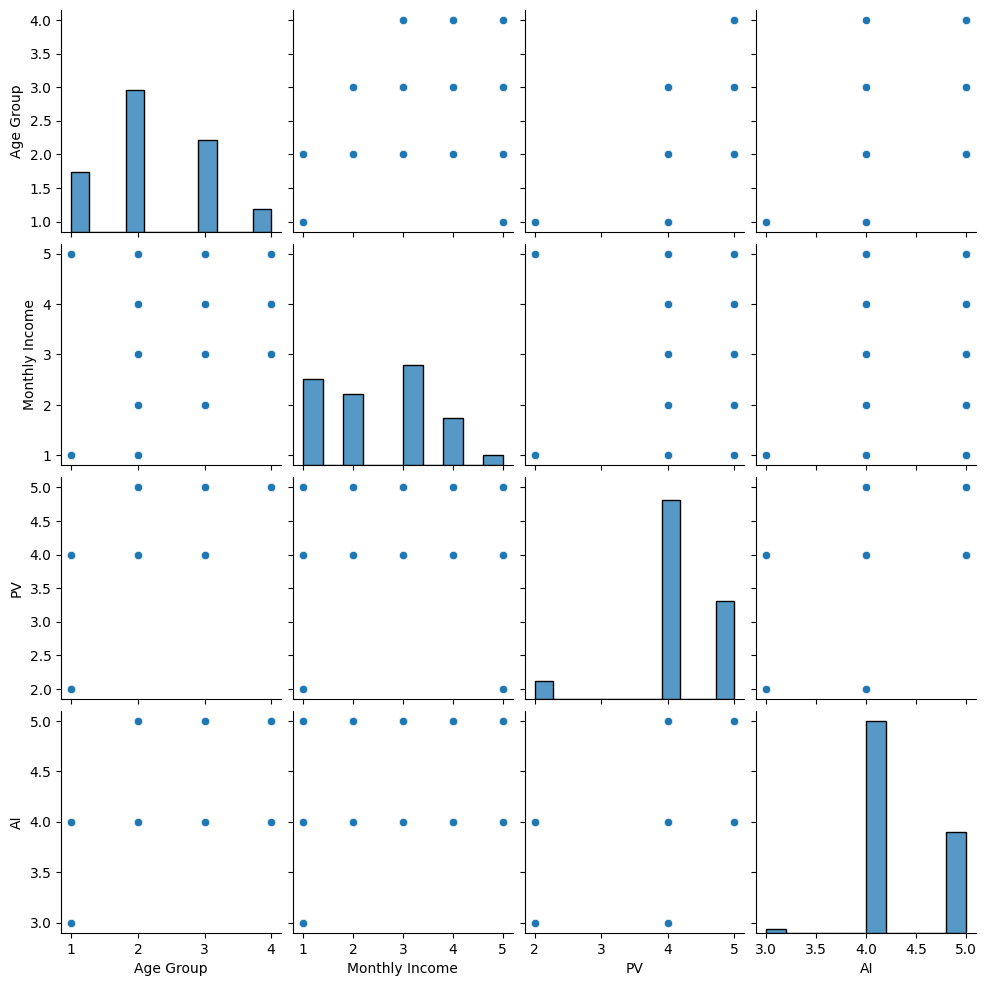

In [ ]:
# Pair Plot for Numeric Variables
sns.pairplot(data[['Age Group', 'Monthly Income', 'PV', 'AI']])
plt.show()

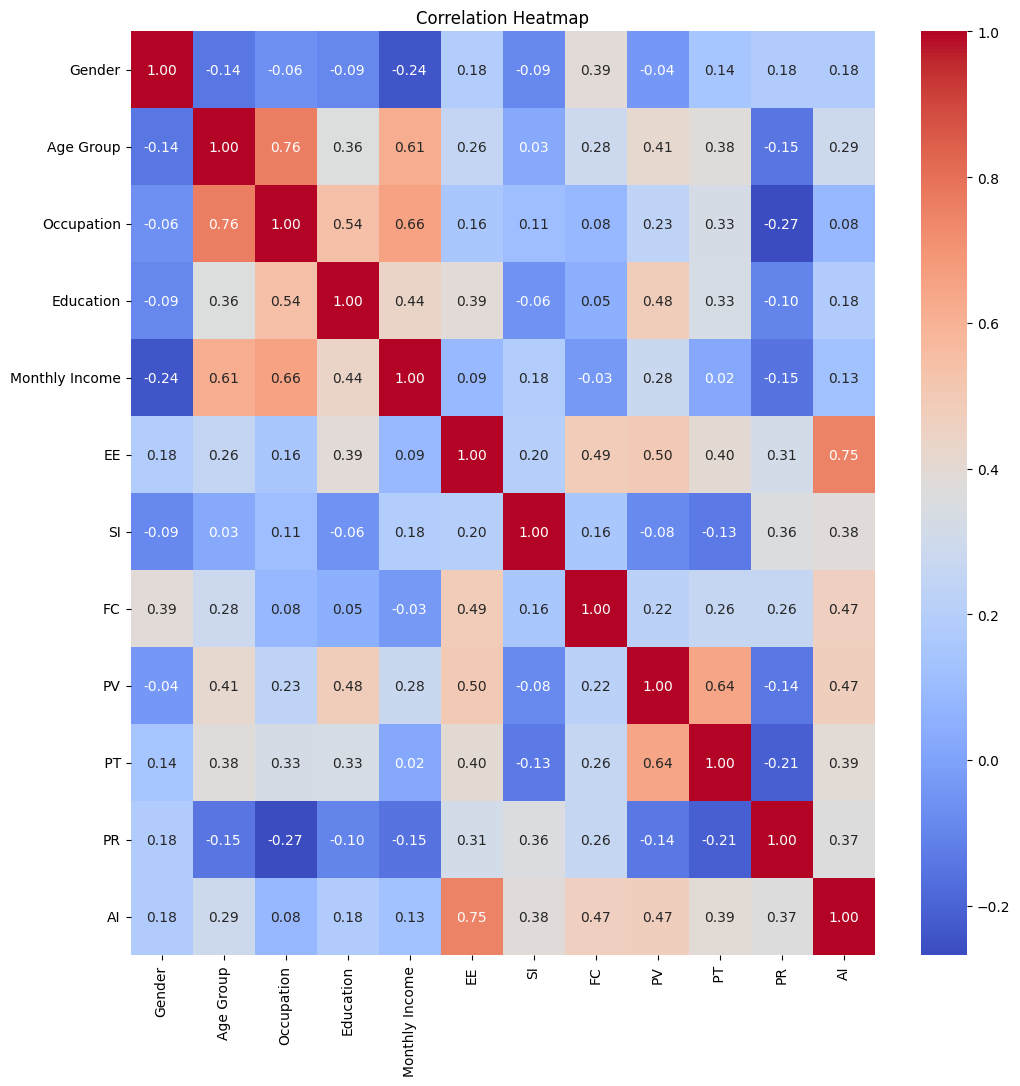

In [ ]:
 # Correlation Heatmap
plt.figure(figsize=(12, 12))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Manupulation**

In [ ]:
 #Check the distribution of target variables
target_variables = ['AI']

for target in target_variables:
    print(f"Distribution of '{target}':")
    print(data[target].value_counts())
    print("\n")


Distribution of 'AI':
AI
4    251
5    120
3      4
Name: count, dtype: int64




In [ ]:
# Encode the target variable
label_encoder = LabelEncoder()
for column in ['AI']:
    data[column] = label_encoder.fit_transform(data[column])

In [ ]:
# Split the data into features (X) and target variable (y)
X = data.drop(['AI'], axis=1)
y = data['AI']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# List of models
models_name = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
}

In [ ]:
# Split the data into features (X) and target variable (y)
X = data.drop(['AI'], axis=1)
y = data['AI']

In [ ]:
# Iterate over models
for name, model in models_name.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    print(f"Evaluating {name}...")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy of {name}: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("="*60)

Training Logistic Regression...
Evaluating Logistic Regression...
Accuracy of Logistic Regression: 0.9733
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.98      0.98      0.98        44
           2       0.97      1.00      0.98        30

    accuracy                           0.97        75
   macro avg       0.65      0.66      0.65        75
weighted avg       0.96      0.97      0.97        75

Training Random Forest...
Evaluating Random Forest...


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

Accuracy of Random Forest: 0.9733
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.98      0.98      0.98        44
           2       0.97      1.00      0.98        30

    accuracy                           0.97        75
   macro avg       0.65      0.66      0.65        75
weighted avg       0.96      0.97      0.97        75

Training Support Vector Machine...
Evaluating Support Vector Machine...
Accuracy of Support Vector Machine: 0.9733
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.98      0.98      0.98        44
           2       0.97      1.00      0.98        30

    accuracy                           0.97        75
   macro avg       0.65      0.66      0.65        75
weighted avg       0.96      0.97      0.97        75

Training K-Nearest Neighbors...
Evaluating K-Nearest Neighbors...
Accuracy of K-Nearest N

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

In [ ]:
!pip install scikit-learn
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# ... (rest of your imports)

# Split the data into features (X) and target variable (y)
X = data.drop('AI', axis=1)
y = data['AI']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute missing values using the mean
imputer = SimpleImputer(strategy='mean')  # You can also use 'median' or other strategies
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ... (rest of your code for model training and evaluation)

<ipython-input-56-eea16b1734ff>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_model_names, y=sorted_accuracies, palette=palette)


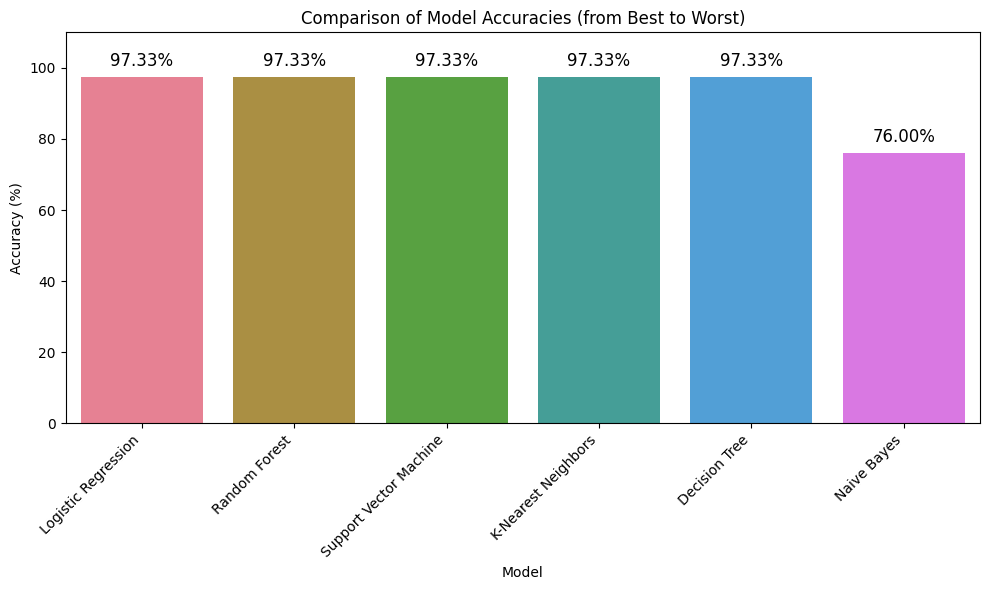

Model rankings (from Best to Worst Accuracy):
1. Logistic Regression: 0.9733
2. Random Forest: 0.9733
3. Support Vector Machine: 0.9733
4. K-Nearest Neighbors: 0.9733
5. Decision Tree: 0.9733
6. Naive Bayes: 0.7600


In [ ]:
# Iterate over models and calculate accuracy
model_accuracies = {}  # Initialize model_accuracies as an empty dictionary

# Iterate over models and calculate accuracy
for name, model in models_name.items():
    model.fit(X_train, y_train)  # Fit the model to the training data

    # Predict the labels for the test data
    y_pred = model.predict(X_test)

    # Calculate the accuracy of the model
    accuracy = accuracy_score(y_test, y_pred)

    # Store the accuracy of the current model
    model_accuracies[name] = accuracy

# Sort the models by accuracy in descending order (best to worst)
sorted_models = sorted(model_accuracies.items(), key=lambda x: x[1], reverse=True)

# Prepare data for the bar chart
sorted_model_names = [model[0] for model in sorted_models]
sorted_accuracies = [model[1] * 100 for model in sorted_models]  # Convert accuracy to percentage

# Plot the comparison bar plot with sorted models
plt.figure(figsize=(10, 6))

# Get a default color palette with enough colors for all models
palette = sns.color_palette("husl", len(sorted_model_names))


# Create the bar plot
sns.barplot(x=sorted_model_names, y=sorted_accuracies, palette=palette)

# Add accuracy values on top of each bar
for index, accuracy in enumerate(sorted_accuracies):
    plt.text(index, accuracy + 2, f'{accuracy:.2f}%', color='black', ha='center', va='bottom', fontsize=12)

# Set labels and title
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Model Accuracies (from Best to Worst)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Set y-axis limit to 100% for visibility of differences
plt.ylim(0, 110)

# Ensure the layout is tight to avoid clipping of labels
plt.tight_layout()

# Display the plot
plt.show()

# Print the models and their accuracies in sorted order
print("Model rankings (from Best to Worst Accuracy):")
for rank, (name, accuracy) in enumerate(sorted_models, start=1):
    print(f"{rank}. {name}: {accuracy:.4f}")

In [ ]:
# Using like 5-fold cross-validation to see if the models perform consistently across different subsets of the data.

from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer



# Number of folds for cross-validation
num_folds = 4

# Create an imputer to handle missing values
imputer = SimpleImputer(strategy='mean')  # or 'median', etc.

# Iterate over models and perform cross-validation
for name, model in models_name.items():
    print(f"Performing {num_folds}-fold cross-validation for {name}...")

    # Impute missing values within the cross-validation loop
    cv_scores = cross_val_score(model, imputer.fit_transform(X), y, cv=num_folds)

    print(f"Cross-validation scores: {cv_scores}")
    print(f"Average accuracy: {np.mean(cv_scores):.4f}")
    print(f"Standard deviation: {np.std(cv_scores):.4f}")
    print("=" * 60)

Performing 4-fold cross-validation for Logistic Regression...


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-validation scores: [0.96808511 0.93617021 0.9787234  0.98924731]
Average accuracy: 0.9681
Standard deviation: 0.0199
Performing 4-fold cross-validation for Random Forest...
Cross-validation scores: [0.96808511 0.94680851 0.9787234  0.98924731]
Average accuracy: 0.9707
Standard deviation: 0.0157
Performing 4-fold cross-validation for Support Vector Machine...
Cross-validation scores: [0.96808511 0.94680851 0.9787234  0.98924731]
Average accuracy: 0.9707
Standard deviation: 0.0157
Performing 4-fold cross-validation for K-Nearest Neighbors...
Cross-validation scores: [0.96808511 0.94680851 0.9787234  0.97849462]
Average accuracy: 0.9680
Standard deviation: 0.0130
Performing 4-fold cross-validation for Decision Tree...
Cross-validation scores: [0.96808511 0.94680851 0.9787234  0.98924731]
Average accuracy: 0.9707
Standard deviation: 0.0157
Performing 4-fold cross-validation for Naive Bayes...
Cross-validation scores: [0.73404255 0.76595745 0.67021277 0.83870968]
Average accuracy: 0.7

In [ ]:
# Using like 4-fold cross-validation to see if the models perform consistently across different subsets of the data.

from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer


# Number of folds for cross-validation
num_folds = 4

# Create an imputer to handle missing values
imputer = SimpleImputer(strategy='mean')  # or 'median', etc.

# List of models #this should be outside the for loop
models_name = {
    "Logistic Regression": LogisticRegression(random_state=42),  # Add this line
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
}
# Iterate over models and perform cross-validation
for name, model in models_name.items():
    print(f"Performing {num_folds}-fold cross-validation for {name}...")


    # Impute missing values within the cross-validation loop
    cv_scores = cross_val_score(model, imputer.fit_transform(X), y, cv=num_folds)

    print(f"Cross-validation scores: {cv_scores}")
    print(f"Average accuracy: {np.mean(cv_scores):.4f}")
    print(f"Standard deviation: {np.std(cv_scores):.4f}")
    print("=" * 60)

Performing 4-fold cross-validation for Logistic Regression...
Cross-validation scores: [0.96808511 0.93617021 0.9787234  0.98924731]
Average accuracy: 0.9681
Standard deviation: 0.0199
Performing 4-fold cross-validation for Random Forest...


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-validation scores: [0.96808511 0.94680851 0.9787234  0.98924731]
Average accuracy: 0.9707
Standard deviation: 0.0157
Performing 4-fold cross-validation for Support Vector Machine...
Cross-validation scores: [0.96808511 0.94680851 0.9787234  0.98924731]
Average accuracy: 0.9707
Standard deviation: 0.0157
Performing 4-fold cross-validation for K-Nearest Neighbors...
Cross-validation scores: [0.96808511 0.94680851 0.9787234  0.97849462]
Average accuracy: 0.9680
Standard deviation: 0.0130
Performing 4-fold cross-validation for Decision Tree...
Cross-validation scores: [0.96808511 0.94680851 0.9787234  0.98924731]
Average accuracy: 0.9707
Standard deviation: 0.0157
Performing 4-fold cross-validation for Naive Bayes...
Cross-validation scores: [0.73404255 0.76595745 0.67021277 0.83870968]
Average accuracy: 0.7522
Standard deviation: 0.0607


In [ ]:
data.columns

Index(['Gender', 'Age Group', 'Occupation', 'Education', 'Monthly Income',
       'EE', 'SI', 'FC', 'PV', ' PT', 'PR', 'AI'],
      dtype='object')

**END**
